# EV Charging Time Prediction Using Regression

## Project objective
Predict **EV charging time (minutes)** from charging and battery-related information.

### Problem statement
Charging time depends on several factors such as charger power, required energy, battery condition, temperature, and charging efficiency. This project uses regression models to learn the relationship between these inputs and the actual charging time.

### Why regression?
`charging_time_min` is a continuous numerical value, so regression is suitable.

### Models
1. **Simple Linear Regression** — baseline using only charger power.
2. **Multiple Linear Regression** — uses all selected features.
3. **Polynomial Regression** — adds polynomial relationships and tests degrees 2–5.

> **Dataset note:** This is a synthetic educational dataset, not real-world EV charging-session data.

## 2. Dataset Description

| Column | Meaning | Unit |
|---|---|---|
| `battery_capacity_kwh` | Battery capacity | kWh |
| `initial_soc` | Starting state of charge | % |
| `target_soc` | Desired state of charge | % |
| `charger_power_kw` | Charger power | kW |
| `temperature_c` | Temperature | °C |
| `battery_health` | Battery health | % |
| `charging_efficiency` | Charging efficiency | decimal |
| `charging_time_min` | Actual charging time — **target** | minutes |

The dataset is synthetic and created for educational regression testing.

## 3. Import Libraries

We use pandas for data handling, NumPy for numerical calculations, matplotlib/seaborn for visualization, and scikit-learn for splitting data, models, feature engineering, and evaluation.

In [24]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 4. Automatically Find the Dataset

Kaggle can assign different folder names to datasets. Therefore, this notebook searches `/kaggle/input/` instead of using a hard-coded dataset path.

In [25]:
csv_files = glob.glob("/kaggle/input/**/*.csv", recursive=True)

print("CSV files found:")
for file in csv_files:
    print(file)

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV file found. Please use Kaggle's Add Data option to attach the dataset."
    )

if len(csv_files) > 1:
    print("\nMultiple CSV files found. The notebook will prefer a file containing 'ev_charging'.")

ev_files = [f for f in csv_files if "ev_charging" in f.lower()]
DATA_PATH = ev_files[0] if ev_files else csv_files[0]

df = pd.read_csv(DATA_PATH)

print("\nDataset loaded successfully!")
print("Path:", DATA_PATH)
print("Shape:", df.shape)

CSV files found:
/kaggle/input/datasets/harsha050406/ev-data-set/ev_charging_time_dataset_lite_1MB.csv

Dataset loaded successfully!
Path: /kaggle/input/datasets/harsha050406/ev-data-set/ev_charging_time_dataset_lite_1MB.csv
Shape: (600, 8)


## 5. Understand the Data

- `head()` shows the first rows.
- `tail()` shows the last rows.
- `shape` gives rows and columns.
- `columns` lists column names.
- `info()` shows data types and missing values.
- `describe()` gives numerical summary statistics.

In [26]:
display(df.head())
display(df.tail())
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.info()
display(df.describe())

,battery_capacity_kwh,initial_soc,target_soc,charger_power_kw,temperature_c,battery_health,charging_efficiency,charging_time_min
0,56.2,19.3,88.6,150.0,18.6,91.8,0.931,27.08
1,96.6,25.3,46.9,100.0,7.9,94.9,0.906,14.65
2,81.2,19.7,41.1,22.0,21.4,81.3,0.935,52.75
3,71.9,14.9,55.9,11.0,17.4,90.6,0.934,171.63
4,40.9,16.6,68.4,22.0,32.1,89.3,0.936,62.29


,battery_capacity_kwh,initial_soc,target_soc,charger_power_kw,temperature_c,battery_health,charging_efficiency,charging_time_min
595,63.2,57.9,83.4,22.0,39.6,91.1,0.933,48.70
596,76.7,63.5,95.0,11.0,11.3,80.7,0.925,154.08
597,42.1,63.3,88.0,7.2,17.4,88.8,0.935,100.47
598,43.5,51.2,75.8,50.0,16.6,84.3,0.936,11.71
599,32.9,17.2,38.0,50.0,39.9,91.5,0.944,10.63


Shape: (600, 8)
Columns: ['battery_capacity_kwh', 'initial_soc', 'target_soc', 'charger_power_kw', 'temperature_c', 'battery_health', 'charging_efficiency', 'charging_time_min']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   battery_capacity_kwh  600 non-null    float64
 1   initial_soc           600 non-null    float64
 2   target_soc            600 non-null    float64
 3   charger_power_kw      600 non-null    float64
 4   temperature_c         600 non-null    float64
 5   battery_health        600 non-null    float64
 6   charging_efficiency   600 non-null    float64
 7   charging_time_min     600 non-null    float64
dtypes: float64(8)
memory usage: 37.6 KB


,battery_capacity_kwh,initial_soc,target_soc,charger_power_kw,temperature_c,battery_health,charging_efficiency,charging_time_min
count,600.00000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,65.21300,37.240000,82.277667,59.504333,25.194833,87.383000,0.929222,97.819367
std,20.88491,16.003951,15.523933,50.849260,11.743892,7.086643,0.015091,109.773131
min,30.40000,10.300000,35.200000,7.200000,5.000000,75.000000,0.887000,6.080000
25%,46.90000,22.800000,72.000000,11.000000,15.775000,81.200000,0.919000,26.872500
50%,66.20000,37.500000,89.600000,50.000000,24.950000,87.600000,0.930000,47.690000
75%,83.42500,51.125000,95.000000,100.000000,35.600000,93.300000,0.940000,131.960000
max,100.00000,64.900000,95.000000,150.000000,44.900000,100.000000,0.973000,648.650000


## 6. Check Data Quality

We check missing values and duplicate rows. Duplicate rows are removed. Valid numerical data is not unnecessarily changed.

In [27]:
print("Missing values:")
display(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().copy()

# Handle missing values only where needed.
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    elif df[col].isnull().any():
        mode = df[col].mode()
        df[col] = df[col].fillna(mode.iloc[0] if not mode.empty else "Unknown")

print("Shape after duplicate removal:", df.shape)

Missing values:


battery_capacity_kwh    0
initial_soc             0
target_soc              0
charger_power_kw        0
temperature_c           0
battery_health          0
charging_efficiency     0
charging_time_min       0
dtype: int64

Duplicate rows: 0
Shape after duplicate removal: (600, 8)


## 7. Data Validation

The checks below identify whether each required physical/range condition is satisfied.

In [28]:
validation = pd.DataFrame({
    "Check": [
        "Battery capacity > 0",
        "Initial SOC between 0 and 100",
        "Target SOC between 0 and 100",
        "Target SOC greater than initial SOC",
        "Charger power > 0",
        "Battery health between 0 and 100",
        "Charging efficiency > 0 and <= 1",
        "Charging time > 0"
    ],
    "Valid rows": [
        (df["battery_capacity_kwh"] > 0).sum(),
        df["initial_soc"].between(0, 100).sum(),
        df["target_soc"].between(0, 100).sum(),
        (df["target_soc"] > df["initial_soc"]).sum(),
        (df["charger_power_kw"] > 0).sum(),
        df["battery_health"].between(0, 100).sum(),
        df["charging_efficiency"].between(0, 1, inclusive="right").sum(),
        (df["charging_time_min"] > 0).sum()
    ],
    "Total rows": len(df)
})
display(validation)

,Check,Valid rows,Total rows
0,Battery capacity > 0,600,600
1,Initial SOC between 0 and 100,600,600
2,Target SOC between 0 and 100,600,600
3,Target SOC greater than initial SOC,600,600
4,Charger power > 0,600,600
5,Battery health between 0 and 100,600,600
6,Charging efficiency > 0 and <= 1,600,600
7,Charging time > 0,600,600


## 8. Feature Engineering

### SOC Difference
`target_soc - initial_soc` tells us how much the battery SOC must increase.

### Energy Required
`battery_capacity_kwh × soc_difference / 100` estimates the energy needed.

Example: a 60 kWh battery charging from 20% to 80% needs a 60% SOC increase, so approximately `60 × 60 / 100 = 36 kWh`.

These features are useful because charging time is related to how much energy is required and how quickly the charger can deliver it.

In [29]:
df["soc_difference"] = df["target_soc"] - df["initial_soc"]
df["energy_required_kwh"] = (
    df["battery_capacity_kwh"] * df["soc_difference"] / 100
)

display(df[[
    "battery_capacity_kwh", "initial_soc", "target_soc",
    "soc_difference", "energy_required_kwh", "charging_time_min"
]].head())

,battery_capacity_kwh,initial_soc,target_soc,soc_difference,energy_required_kwh,charging_time_min
0,56.2,19.3,88.6,69.3,38.9466,27.08
1,96.6,25.3,46.9,21.6,20.8656,14.65
2,81.2,19.7,41.1,21.4,17.3768,52.75
3,71.9,14.9,55.9,41.0,29.4790,171.63
4,40.9,16.6,68.4,51.8,21.1862,62.29


## 9. Exploratory Data Analysis

Each graph is kept separate so the relationship is easy to inspect.

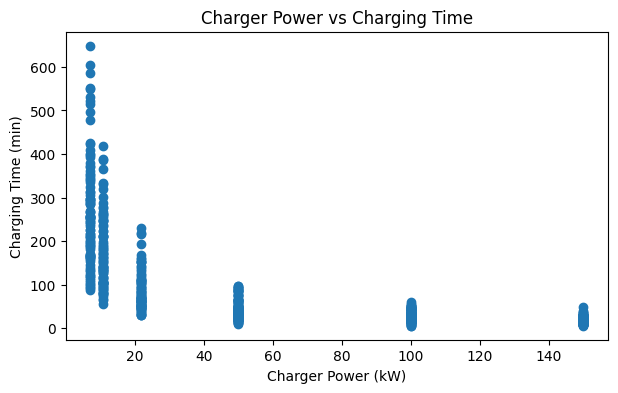

In [30]:
plt.figure(figsize=(7, 4))
plt.scatter(df["charger_power_kw"], df["charging_time_min"])
plt.xlabel("Charger Power (kW)")
plt.ylabel("Charging Time (min)")
plt.title("Charger Power vs Charging Time")
plt.show()

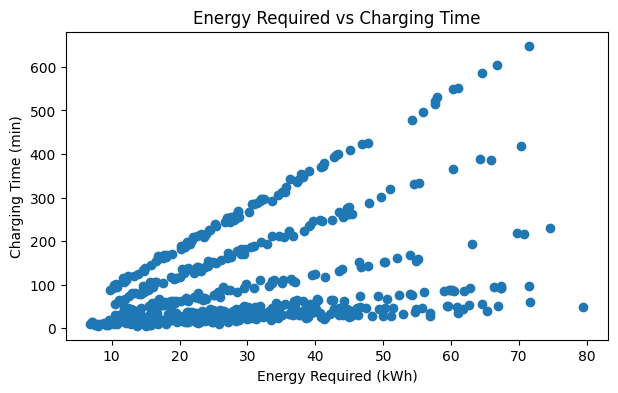

In [31]:
plt.figure(figsize=(7, 4))
plt.scatter(df["energy_required_kwh"], df["charging_time_min"])
plt.xlabel("Energy Required (kWh)")
plt.ylabel("Charging Time (min)")
plt.title("Energy Required vs Charging Time")
plt.show()

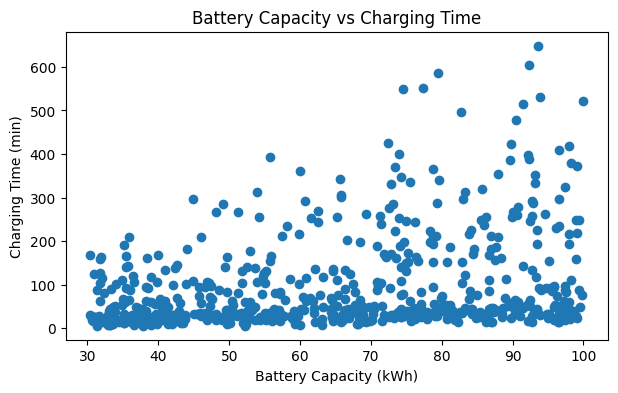

In [32]:
plt.figure(figsize=(7, 4))
plt.scatter(df["battery_capacity_kwh"], df["charging_time_min"])
plt.xlabel("Battery Capacity (kWh)")
plt.ylabel("Charging Time (min)")
plt.title("Battery Capacity vs Charging Time")
plt.show()

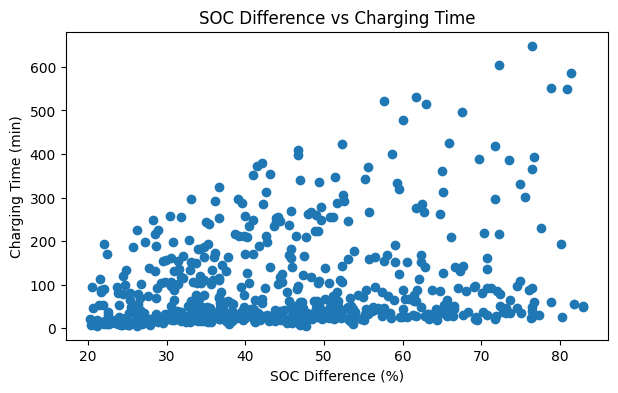

In [33]:
plt.figure(figsize=(7, 4))
plt.scatter(df["soc_difference"], df["charging_time_min"])
plt.xlabel("SOC Difference (%)")
plt.ylabel("Charging Time (min)")
plt.title("SOC Difference vs Charging Time")
plt.show()

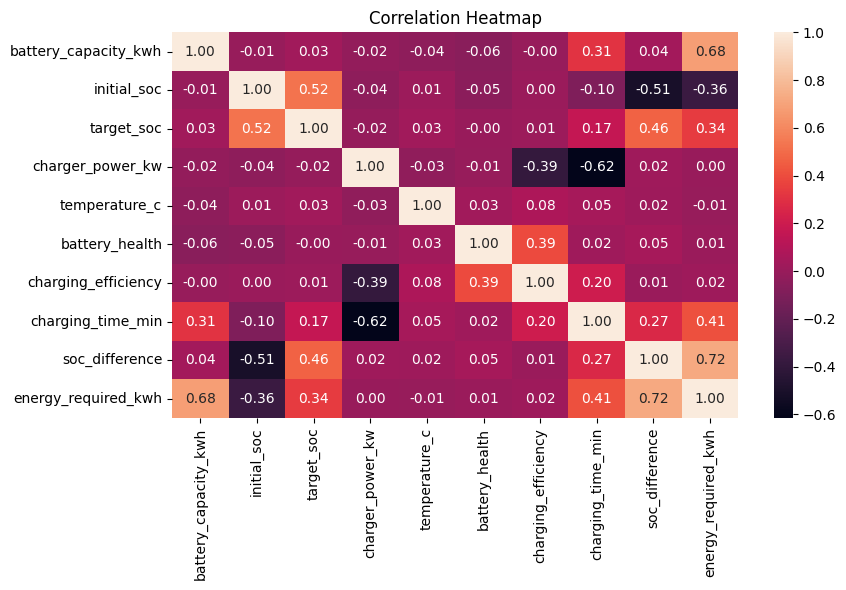

In [34]:
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 10. Features and Target

`X` contains the input features. `y` contains the value we want to predict.

In [35]:
FEATURES = [
    "battery_capacity_kwh",
    "initial_soc",
    "target_soc",
    "charger_power_kw",
    "temperature_c",
    "battery_health",
    "charging_efficiency",
    "soc_difference",
    "energy_required_kwh"
]

TARGET = "charging_time_min"

X = df[FEATURES]
y = df[TARGET]

print("Number of features:", len(FEATURES))
print("Target:", TARGET)

Number of features: 9
Target: charging_time_min


## 11. Train-Test Split

80% of the data is used for training and 20% for testing. `random_state=42` makes the split reproducible.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 480
Testing rows: 120


# Model 1 — Simple Linear Regression

This is the baseline model. It uses **only `charger_power_kw`** as input.

The coefficient describes the fitted change in predicted charging time per unit increase in charger power within this dataset. The intercept is the fitted prediction when charger power is zero; it is mainly a mathematical model parameter here.

**MAE:** average absolute error in minutes.  
**RMSE:** penalizes larger errors more strongly.  
**R²:** variation in the test target explained by the model; interpret with MAE/RMSE.

In [37]:
X_simple = df[["charger_power_kw"]]
y_simple = df["charging_time_min"]

X_simple_train, X_simple_test, y_simple_train, y_simple_test = train_test_split(
    X_simple, y_simple, test_size=0.20, random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_simple_train, y_simple_train)

simple_pred = simple_model.predict(X_simple_test)

simple_mae = mean_absolute_error(y_simple_test, simple_pred)
simple_rmse = np.sqrt(mean_squared_error(y_simple_test, simple_pred))
simple_r2 = r2_score(y_simple_test, simple_pred)

print("========== SIMPLE LINEAR REGRESSION ==========")
print("Intercept:", simple_model.intercept_)
print("Coefficient:", simple_model.coef_[0])
print("MAE:", simple_mae)
print("RMSE:", simple_rmse)
print("R²:", simple_r2)

========== SIMPLE LINEAR REGRESSION ==========
Intercept: 173.40134042810712
Coefficient: -1.2754728996857554
MAE: 63.89540387513937
RMSE: 96.35032528053738
R²: 0.3526915899296923


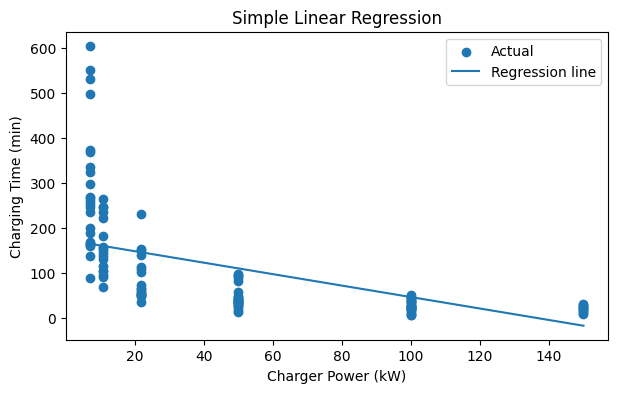

In [38]:
plt.figure(figsize=(7, 4))
plt.scatter(X_simple_test["charger_power_kw"], y_simple_test, label="Actual")
order = np.argsort(X_simple_test["charger_power_kw"].values)
plt.plot(
    X_simple_test["charger_power_kw"].values[order],
    simple_pred[order],
    label="Regression line"
)
plt.xlabel("Charger Power (kW)")
plt.ylabel("Charging Time (min)")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

## Model 2 — Multiple Linear Regression

This model uses all selected features simultaneously. It can therefore consider battery size, SOC, charger power, temperature, battery health, efficiency, SOC difference, and energy required together.

In [39]:
multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train)

multiple_pred = multiple_model.predict(X_test)

multiple_mae = mean_absolute_error(y_test, multiple_pred)
multiple_rmse = np.sqrt(mean_squared_error(y_test, multiple_pred))
multiple_r2 = r2_score(y_test, multiple_pred)

print("========== MULTIPLE LINEAR REGRESSION ==========")
print("MAE:", multiple_mae)
print("RMSE:", multiple_rmse)
print("R²:", multiple_r2)

coefficients = pd.DataFrame({
    "Feature": FEATURES,
    "Coefficient": multiple_model.coef_
})
display(coefficients)

========== MULTIPLE LINEAR REGRESSION ==========
MAE: 58.328054366085674
RMSE: 80.72547822935985
R²: 0.5456127546289016


,Feature,Coefficient
0,battery_capacity_kwh,0.128972
1,initial_soc,0.177525
2,target_soc,0.103983
3,charger_power_kw,-1.321034
4,temperature_c,0.106980
5,battery_health,0.691039
6,charging_efficiency,-443.455895
7,soc_difference,-0.073542
8,energy_required_kwh,2.974080


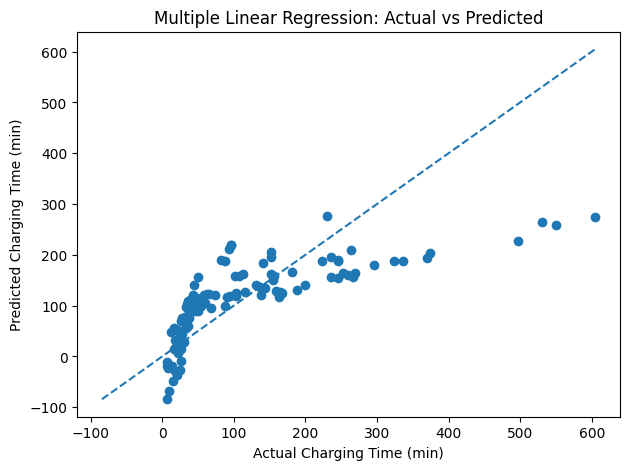

In [40]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, multiple_pred)
min_v = min(y_test.min(), multiple_pred.min())
max_v = max(y_test.max(), multiple_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.xlabel("Actual Charging Time (min)")
plt.ylabel("Predicted Charging Time (min)")
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.show()

## Model 3 — Polynomial Regression

Polynomial features allow the linear regression model to represent nonlinear relationships.

We test degrees **2, 3, 4, and 5** using the same multiple features. Results are calculated when the notebook runs — nothing is hard-coded.

In [41]:
polynomial_results = []
polynomial_models = {}

for degree in [2, 3, 4, 5]:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linear", LinearRegression())
    ])

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    polynomial_models[degree] = model
    polynomial_results.append({
        "Degree": degree,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

polynomial_results_df = pd.DataFrame(polynomial_results)

print("========== POLYNOMIAL REGRESSION RESULTS ==========")
display(polynomial_results_df)

best_degree = polynomial_results_df.loc[
    polynomial_results_df["RMSE"].idxmin(), "Degree"
]
best_poly_model = polynomial_models[int(best_degree)]

print(f"Degree selected by lowest test RMSE: {int(best_degree)}")
print("This is only a selection criterion for this experiment, not a universal rule.")

========== POLYNOMIAL REGRESSION RESULTS ==========


,Degree,MAE,RMSE,R²
0,2,38.136035,53.413681,0.801066
1,3,25.937729,36.346162,0.907887
2,4,55.554029,82.541334,0.524941
3,5,48.203462,83.032852,0.519266


Degree selected by lowest test RMSE: 3
This is only a selection criterion for this experiment, not a universal rule.


## Final Model Comparison

Compare the three experiments using the metrics generated above. Lower MAE/RMSE generally means smaller prediction error; R² should be interpreted together with the error metrics.

In [42]:
final_comparison = pd.DataFrame([
    {
        "Model": "Simple Linear Regression",
        "MAE": simple_mae,
        "RMSE": simple_rmse,
        "R²": simple_r2
    },
    {
        "Model": "Multiple Linear Regression",
        "MAE": multiple_mae,
        "RMSE": multiple_rmse,
        "R²": multiple_r2
    },
    {
        "Model": f"Polynomial Regression (degree {int(best_degree)})",
        "MAE": polynomial_results_df.loc[
            polynomial_results_df["Degree"] == best_degree, "MAE"
        ].iloc[0],
        "RMSE": polynomial_results_df.loc[
            polynomial_results_df["Degree"] == best_degree, "RMSE"
        ].iloc[0],
        "R²": polynomial_results_df.loc[
            polynomial_results_df["Degree"] == best_degree, "R²"
        ].iloc[0]
    }
])

display(final_comparison)

,Model,MAE,RMSE,R²
0,Simple Linear Regression,63.895404,96.350325,0.352692
1,Multiple Linear Regression,58.328054,80.725478,0.545613
2,Polynomial Regression (degree 3),25.937729,36.346162,0.907887


## Residual Analysis — Multiple Linear Regression

A residual is `actual value - predicted value`. The plot helps inspect whether errors appear randomly distributed around zero.

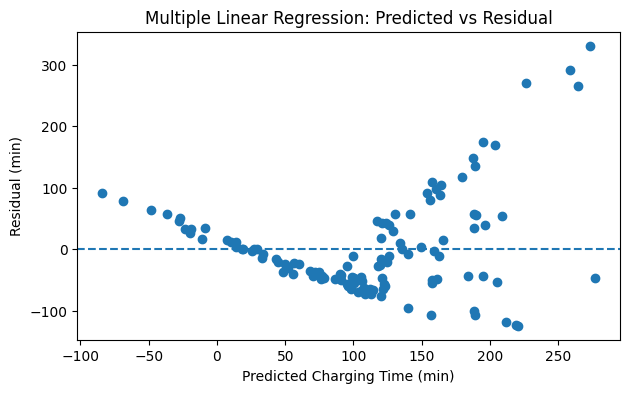

In [43]:
residuals = y_test - multiple_pred

plt.figure(figsize=(7, 4))
plt.scatter(multiple_pred, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Charging Time (min)")
plt.ylabel("Residual (min)")
plt.title("Multiple Linear Regression: Predicted vs Residual")
plt.show()

## New EV Prediction

The following example uses the requested values. The engineered features are calculated automatically, then the Multiple Linear Regression model predicts charging time.

In [44]:
new_ev = pd.DataFrame([{
    "battery_capacity_kwh": 67,
    "initial_soc": 20,
    "target_soc": 70,
    "charger_power_kw": 40,
    "temperature_c": 20,
    "battery_health": 75,
    "charging_efficiency": 0.90
}])

new_ev["soc_difference"] = new_ev["target_soc"] - new_ev["initial_soc"]
new_ev["energy_required_kwh"] = (
    new_ev["battery_capacity_kwh"] * new_ev["soc_difference"] / 100
)

new_multiple_prediction = multiple_model.predict(new_ev[FEATURES])[0]

print("SOC Difference:", new_ev["soc_difference"].iloc[0], "%")
print("Energy Required:", new_ev["energy_required_kwh"].iloc[0], "kWh")
print(f"Predicted Charging Time: {new_multiple_prediction:.2f} minutes")
print(f"Predicted Charging Time: {new_multiple_prediction / 60:.2f} hours")

SOC Difference: 50 %
Energy Required: 33.5 kWh
Predicted Charging Time: 134.36 minutes
Predicted Charging Time: 2.24 hours


## Test All Three Models With the New EV

The simple model receives only charger power. The multiple and polynomial models receive all required features.

In [45]:
simple_new_prediction = simple_model.predict(
    new_ev[["charger_power_kw"]]
)[0]

multiple_new_prediction = multiple_model.predict(
    new_ev[FEATURES]
)[0]

polynomial_new_prediction = best_poly_model.predict(
    new_ev[FEATURES]
)[0]

new_ev_predictions = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression",
        f"Polynomial Regression (degree {int(best_degree)})"
    ],
    "Predicted Charging Time (min)": [
        simple_new_prediction,
        multiple_new_prediction,
        polynomial_new_prediction
    ]
})

display(new_ev_predictions)

,Model,Predicted Charging Time (min)
0,Simple Linear Regression,122.382424
1,Multiple Linear Regression,134.361922
2,Polynomial Regression (degree 3),36.672515


## Custom EV Test

Change the values in the cell below and run it. The notebook automatically calculates SOC difference and energy required, then produces predictions from all three trained models.

In [46]:
# Change these values for your own test EV
battery_capacity = 75
initial_soc = 15
target_soc = 90
charger_power = 100
temperature = 30
battery_health = 90
efficiency = 0.91

custom_ev = pd.DataFrame([{
    "battery_capacity_kwh": battery_capacity,
    "initial_soc": initial_soc,
    "target_soc": target_soc,
    "charger_power_kw": charger_power,
    "temperature_c": temperature,
    "battery_health": battery_health,
    "charging_efficiency": efficiency
}])

custom_ev["soc_difference"] = custom_ev["target_soc"] - custom_ev["initial_soc"]
custom_ev["energy_required_kwh"] = (
    custom_ev["battery_capacity_kwh"] * custom_ev["soc_difference"] / 100
)

custom_predictions = {
    "Simple Linear Regression": simple_model.predict(
        custom_ev[["charger_power_kw"]]
    )[0],
    "Multiple Linear Regression": multiple_model.predict(
        custom_ev[FEATURES]
    )[0],
    f"Polynomial Regression (degree {int(best_degree)})": best_poly_model.predict(
        custom_ev[FEATURES]
    )[0]
}

print("SOC Difference:", custom_ev["soc_difference"].iloc[0], "%")
print("Energy Required:", custom_ev["energy_required_kwh"].iloc[0], "kWh")
for model_name, prediction in custom_predictions.items():
    print(f"{model_name}: {prediction:.2f} minutes ({prediction/60:.2f} hours)")

SOC Difference: 75 %
Energy Required: 56.25 kWh
Simple Linear Regression: 45.85 minutes (0.76 hours)
Multiple Linear Regression: 130.15 minutes (2.17 hours)
Polynomial Regression (degree 3): 67.56 minutes (1.13 hours)


## Model Evaluation — Simple Explanation

**MAE**  
Average absolute prediction error in minutes. For example, MAE = 10 means predictions are off by about 10 minutes on average on the evaluated test data.

**RMSE**  
Similar to MAE, but larger errors receive more penalty. Lower is generally better.

**R²**  
Shows how much variation in charging time is explained by the model on the test data. Higher is generally better, but it should be interpreted together with MAE and RMSE.

## Final Conclusion — Complete After Running

Do not write a fixed conclusion before running the notebook. Use the generated results to discuss:

- Simple Linear Regression result
- Multiple Linear Regression result
- Polynomial degree results
- MAE
- RMSE
- R²
- Effect of adding multiple features
- Effect of polynomial features
- Limitations

The values in the notebook are generated from the uploaded dataset when you run it.

## Limitations

1. The dataset is synthetic.
2. It is intended for educational purposes.
3. Real EV charging curves are more complex.
4. Battery chemistry is not included.
5. Vehicle-specific charging curves are not included.
6. Charger behavior can vary.
7. Temperature effects can be more complicated.
8. Real-world deployment requires real charging-session data.

# How to Use This Notebook in Kaggle

1. Create a new Kaggle Notebook.
2. Use **Add Data** to attach `ev_charging_time_dataset.csv`.
3. Upload/import this `.ipynb` if your Kaggle workflow supports notebook upload, or copy its cells into Kaggle.
4. Run the notebook from top to bottom.
5. Check the three separate regression experiments and their generated outputs.
6. Use the final comparison table for your project report.

The notebook does not contain the CSV dataset, does not use a fixed Kaggle folder name, and contains no hard-coded model results.